# U-Net Regressor Network

In this notebook, we will be constructing our CNN-based regression network.

In [212]:
import numpy as np

from pathlib import Path
from tqdm import tqdm

# Torch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Diet4Cola imports
from diet4cola.model.models import UNet, ResidualUNet, ResidualUNetLarge
from diet4cola.model.loss import CharbonnierLoss
from diet4cola.utils import load_array, plot_2d_array, plot_curve

## Preprocessing

We first make a function to gather all the filenames on disk and organize them.

In [213]:
data_dir = Path('../data/synthetic')

In [214]:
FILES_PER_EXAMPLE = 5

def gather_examples(dir: Path) -> dict:
    if dir.exists() and dir.is_dir():
        files = [f for f in dir.iterdir() if f.is_file()]
        file_dict = {}
        for file in files:
            identifier = file.name.split('_')[1]
            if identifier in file_dict.keys():
                file_dict[identifier].append(file.name)
            else:
                file_dict[identifier] = [file.name]
    
        # Control, remove any example that does not have 4 entries
        keys_to_pop = []
        for key in file_dict.keys():
            if len(file_dict[key]) != FILES_PER_EXAMPLE:
                keys_to_pop.append(key)

        for key in keys_to_pop:
            file_dict.pop(key, None)

        return file_dict
    return None

example_dictionary = gather_examples(data_dir)
print(f'Found {len(example_dictionary)} examples.')

Found 2 examples.


Next, we create a class that can store our dataset.

In [215]:
# Format string to obtain example
KEY_INPUT_STRING = lambda x: f'cortex_{x}_actomyosin.npy'
KEY_OUTPUT_STRING = lambda x, mode: f'cortex_{x}_velocity_field_{mode}.npy'
KEY_BOUNDARY_STRING = lambda x: f'cortex_{x}_boundary.npy'

In [216]:
class VelocityFieldDataset(Dataset):
    def __init__(self, data_dir: Path, example_dictionary: dict, 
                 split: str = 'train', train_frac: float = 0.8, seed: int = 42):
        self.data_dir = data_dir
        self.example_dictionary = example_dictionary
        self.split = split

        self.vel_dx_mean = 0
        self.vel_dx_std = 0
        self.vel_dy_mean = 0
        self.vel_dy_std = 0
        self.vel_mean = 0
        self.vel_std = 0

        # Make sure split is valid
        assert self.split in ['train', 'val'], 'Split must be \'train\' or \'val\'.'

        # Split keys into train/validation -> TODO: Discuss with Casper if this is good approach for dataset splitting
        all_keys = list(example_dictionary.keys())
        np.random.seed(seed)
        np.random.shuffle(all_keys)
        split_idx = int(len(all_keys) * train_frac)
        if self.split == 'train':
            self.keys = all_keys[:split_idx]
        else:
            self.keys = all_keys[split_idx:]

        # Create examples
        self._create_examples()

    def _extract_example(self, key: str) -> tuple[np.ndarray, np.ndarray]:
        input_example_file = self.data_dir / KEY_INPUT_STRING(key)
        output_example_file_dx = self.data_dir / KEY_OUTPUT_STRING(key, 'dx')
        output_example_file_dy = self.data_dir / KEY_OUTPUT_STRING(key, 'dy')

        input_example = load_array(str(input_example_file))
        output_example_dx = load_array(str(output_example_file_dx))
        output_example_dy = load_array(str(output_example_file_dy))

        # Compute magnitude
        magnitude = np.sqrt(output_example_dx ** 2 + output_example_dy ** 2)
        
        # Put in array
        output_example = np.stack((output_example_dx, output_example_dy, magnitude))

        return (input_example, output_example)

    def _create_examples(self):
        examples = []
        for key in tqdm(self.keys, desc=f'Loading {self.split} examples'):
            boundary_file = self.data_dir / KEY_BOUNDARY_STRING(key)
            boundary = load_array(str(boundary_file))

            input_example, output_example = self._extract_example(key)

            # Check shape
            if input_example.shape != output_example.shape[1:]:
                raise ValueError(f'Input/output shape of examples must match!')
            
            frames = input_example.shape[0]
            for i in range(frames - 1):
                # Extract cortex/field
                cortex_before   = input_example[i, :, :]
                cortex_after    = input_example[i + 1, :, :]
                velocity_output = output_example[:, i, :, :]

                # Stack to obtain one input
                cortex_input    = np.stack([cortex_before, cortex_after], axis=0)

                if np.isnan(cortex_before).any() or np.isnan(cortex_after).any() or np.isnan(velocity_output).any():
                    print(f"NaN detected at frame {i}, skipping...")
                    continue

                # Preprocess to tensor
                cortex_input    = torch.tensor(cortex_input, dtype=torch.float32)
                velocity_output = torch.tensor(velocity_output, dtype=torch.float32)
 
                if torch.isnan(cortex_input).any().item() or torch.isnan(velocity_output).any().item():
                    continue

                examples.append((cortex_input, velocity_output, torch.tensor(boundary, dtype=torch.float32)))

        self.examples = examples

    def __len__(self):
        return len(self.examples)
    
    def __getitem__(self, idx):
        if idx >= self.__len__():
            raise IndexError(f'Index {idx} is out of bounds, only {self.__len__()} examples in dataset.')
        
        cortex_input, velocity_output, boundary = self.examples[idx]

        # Standardize velocity
        vel_dx_out = (velocity_output[0, :, :] - self.vel_dx_mean) / self.vel_dx_std
        vel_dy_out = (velocity_output[1, :, :] - self.vel_dy_mean) / self.vel_dy_std
        vel_magn_out = (velocity_output[2, :, :] - self.vel_mean) / self.vel_std

        velocity_output = torch.stack((vel_dx_out, vel_dy_out, vel_magn_out))

        return cortex_input, velocity_output, boundary

In [217]:
train_frac = 0.5

train_dataset = VelocityFieldDataset(data_dir, example_dictionary, 'train', train_frac=train_frac)
val_dataset = VelocityFieldDataset(data_dir, example_dictionary, 'val', train_frac=train_frac)

Loading val examples: 100%|██████████| 1/1 [00:00<00:00,  7.18it/s]


In [218]:
print(f'Training examples: {train_dataset.__len__()}')
print(f'Validation examples: {val_dataset.__len__()}')

Training examples: 10
Validation examples: 10


## Standardization

Note, this is standardized over the whole spatial domain, resulting in a much lower mean/std than the distribution of initial velocities!

In [219]:
def standardize(dataset: Dataset):
    all_vels_dx = []
    all_vels_dy = []
    all_vels = []
    for inp, vel, _ in dataset.examples:
        all_vels_dx.append(vel[0, :, :].numpy().flatten())
        all_vels_dy.append(vel[1, :, :].numpy().flatten())
        all_vels.append(vel[2, :, :].numpy().flatten())

    all_vels_dx = np.concatenate(all_vels_dx)
    all_vels_dy = np.concatenate(all_vels_dy)
    all_vels = np.concatenate(all_vels)

    vel_dx_mean = all_vels_dx.mean()
    vel_dx_std  = all_vels_dx.std() + 1e-8  # avoid zero division

    vel_dy_mean = all_vels_dy.mean()
    vel_dy_std  = all_vels_dy.std() + 1e-8  # avoid zero division

    vel_mean = all_vels.mean()
    vel_std = all_vels.std() + 1e-8 # avoid zero division

    dataset.vel_dx_mean = vel_dx_mean
    dataset.vel_dx_std  = vel_dx_std

    print(f'Dataset dX: mean = {vel_dx_mean}, std = {vel_dx_std}')

    dataset.vel_dy_mean = vel_dy_mean
    dataset.vel_dy_std  = vel_dy_std

    print(f'Dataset dY: mean = {vel_dy_mean}, std = {vel_dy_std}')

    dataset.vel_mean = vel_mean
    dataset.vel_std = vel_std

    print(f'Dataset mean = {vel_mean}, std = {vel_std}')


In [220]:
standardize(train_dataset)
standardize(val_dataset)

Dataset dX: mean = -0.014204028062522411, std = 0.09138815850019455
Dataset dY: mean = -0.017156686633825302, std = 0.20353814959526062
Dataset mean = 0.07031089812517166, std = 0.21291333436965942
Dataset dX: mean = -0.0010048947297036648, std = 0.7980309128761292
Dataset dY: mean = -0.04250476881861687, std = 1.0903888940811157
Dataset mean = 0.5832434892654419, std = 1.2196075916290283


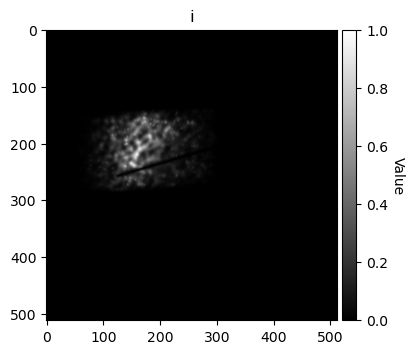

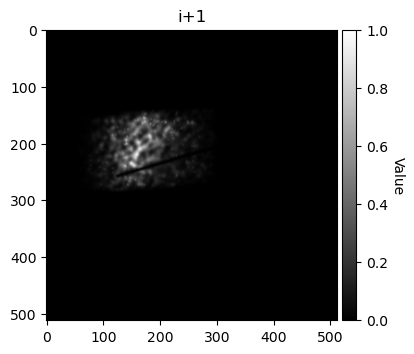

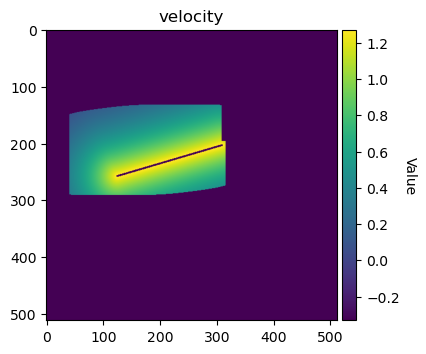

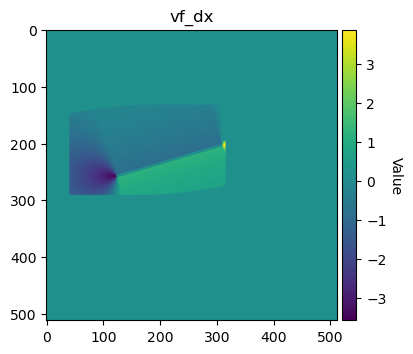

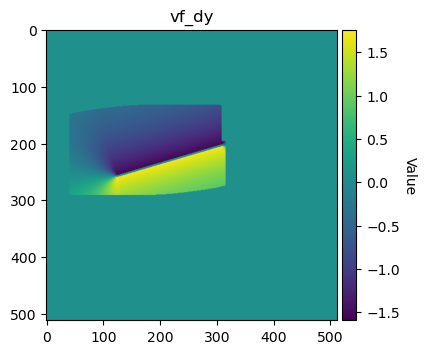

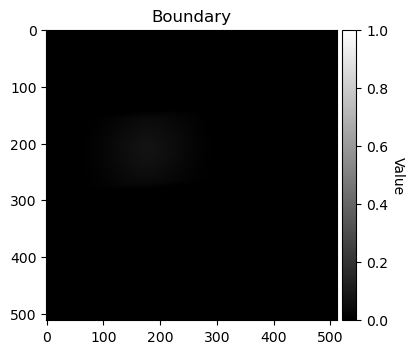

In [221]:

example_in, example_out, example_boundary = train_dataset[7]

example_in = example_in.cpu().detach().numpy()
example_out = example_out.cpu().detach().numpy()
example_boundary = example_boundary.cpu().detach().numpy()

plot_2d_array(example_in[0], 'i')
plot_2d_array(example_in[1], 'i+1')
plot_2d_array(example_out[2], 'velocity', 'viridis', min=np.min(example_out[2]), max=np.max(example_out[2]))
plot_2d_array(example_out[0], 'vf_dx', 'viridis', min=np.min(example_out[0]), max=np.max(example_out[0]))
plot_2d_array(example_out[1], 'vf_dy', 'viridis', min=np.min(example_out[1]), max=np.max(example_out[1]))
plot_2d_array(example_boundary, 'Boundary')


## Model

Now we can define our model implementation. In this notebook, we will experiment with different models. Only the best one is kept.

In [222]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [223]:
# Model
model = ResidualUNet(base_ch=32, in_ch=2, out_ch=3)
model = model.to(device)

## Training

In [224]:
def collate_example(batch):
    # Stack inputs and outputs
    inputs      = torch.stack([item[0] for item in batch], dim=0)
    outputs     = torch.stack([item[1] for item in batch], dim=0)
    boundary    = torch.stack([item[2] for item in batch], dim=0)

    return inputs, outputs, boundary

In [225]:
BATCH_SIZE=4

train_loader    = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_example)
val_loader      = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_example)

**BEFORE TRAINING, MAKE SURE THE CELL ABOVE SAYS 'CUDA' (or wait for an eternity :))**

In [226]:
# Loss function (L1 or L2 for flow estimation)
criterion = nn.MSELoss() # Mean Squared Error (for now)

def smoothness_loss(pred):
    dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]

    return torch.mean(torch.abs(dx)) + torch.mean(torch.abs(dy))

def divergence_loss(u, dx=1.0):
    """
    u: (B, 2, H, W) velocity field
    """
    ux = u[:, 0]  # (B, H, W)
    uy = u[:, 1]

    # finite differences
    dux_dx = ux[:, :, 2:] - ux[:, :, :-2]
    duy_dy = uy[:, 2:, :] - uy[:, :-2, :]

    # center crop to match shapes
    dux_dx = dux_dx[:, :-2, :] / (2 * dx)
    duy_dy = duy_dy[:, :, :-2] / (2 * dx)

    # interior divergence
    div = dux_dx + duy_dy

    return div

In [227]:
# Optimizer
lr = 1e-4
optimizer = optim.Adam(model.parameters(), lr=lr)

In [228]:
def train(epochs: int = 10, validate: bool = True, update_every: bool = False):
    train_loss_on_epoch = []
    val_loss_on_epoch = []

    # Wrap the epoch loop with tqdm
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for inputs, targets, boundary in tqdm(train_loader, desc=f'Epoch {epoch + 1}'):
            inputs = inputs.to(device)
            targets = targets.to(device)
            boundary = boundary.to(device)
            
            targets = targets.unsqueeze(1) if targets.ndim == 3 else targets
            boundary = boundary[0]

            optimizer.zero_grad()
            outputs = model(inputs)
            outputs = outputs[0] if isinstance(outputs, list) else outputs

            l_mse = criterion(outputs * boundary, targets * boundary)
            l_smooth = smoothness_loss(outputs)
            l_div = (divergence_loss(outputs) ** 2).mean()
            loss = l_mse + 0.25 * l_smooth + 0.25 * l_div

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_loader.dataset)
        train_loss_on_epoch.append(train_loss)

        # Your scheduled print
        if (epoch + 1) % 10 == 0 or update_every:
            print(f'Epoch [{epoch + 1}/{epochs}] - Train Loss: {train_loss:.6f}')

        if validate:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for inputs, targets, boundary in val_loader:
                    inputs = inputs.to(device)
                    targets = targets.to(device)
                    boundary = boundary.to(device)

                    targets = targets.unsqueeze(1) if targets.ndim == 3 else targets
                    boundary = boundary[0]

                    outputs = model(inputs)
                    outputs = outputs[0] if isinstance(outputs, list) else outputs

                    l_mse = criterion(outputs * boundary, targets * boundary)
                    l_smooth = smoothness_loss(outputs)
                    l_div = (divergence_loss(outputs) ** 2).mean()
                    loss = l_mse + 0.25 * l_smooth + 0.25 * l_div
                    
                    val_loss += loss.item() * inputs.size(0)

            val_loss /= len(val_loader.dataset)
            val_loss_on_epoch.append(val_loss)

            print(f'Epoch [{epoch + 1}/{epochs}] - Val Loss: {val_loss:.6f}')

    return train_loss_on_epoch, val_loss_on_epoch

In [ ]:
train_loss_on_epoch, val_loss_on_epoch = train(epochs=15, validate=False, update_every=True)

Epoch 1:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
def load(uuid):
    model = UNet(base_ch=32, in_ch=2, out_ch=2)
    model.load_state_dict(torch.load(f'../data/models/model_{uuid}'))
    model.to(device)
    model.eval()

    return model

#model = load('XGvCfLuQeNTQiknJmh4XHu')

In [ ]:
import shortuuid

def save():
    model_uuid = shortuuid.uuid()
    torch.save(model.state_dict(), f'../data/models/model_{model_uuid}')

    return model_uuid

uuid = save()

In [ ]:
def plot_loss_curves(train_loss_on_epoch, val_loss_on_epoch, model_uuid):
    plot_curve(np.array(train_loss_on_epoch), np.arange(1, len(train_loss_on_epoch) + 1, 1), 'Training Loss')
    plot_curve(np.array(val_loss_on_epoch), np.arange(1, len(val_loss_on_epoch) + 1, 1), 'Validation Loss')

    # Save curves
    np.save(Path(f'../data/models/model_{model_uuid}_tloss'), np.array(train_loss_on_epoch))
    np.save(Path(f'../data/models/model_{model_uuid}_vloss'), np.array(train_loss_on_epoch))

plot_loss_curves(train_loss_on_epoch, val_loss_on_epoch, uuid)

* Dataset dX: mean = 0.0006878870772197843, std = 0.21519635617733002
* Dataset dY: mean = -0.0001626248995307833, std = 0.21952974796295166
* Dataset dX: mean = 0.0017635817639529705, std = 0.19021505117416382
* Dataset dY: mean = -0.0005990194040350616, std = 0.20951956510543823

In [ ]:
# Some random test
input_example, output_example, boundary = train_dataset[25]
input_example_vis = input_example.cpu().detach().numpy()
output_example = output_example.cpu().detach().numpy()
boundary = boundary.cpu().detach().numpy()

In [ ]:
print(input_example.shape)

In [ ]:
plot_2d_array(input_example_vis[0], 'Ground Truth', cmap='gray', min=np.min(input_example_vis[0]), max=np.max(input_example_vis[0]))
plot_2d_array(input_example_vis[1], 'Ground Truth', cmap='gray', min=np.min(input_example_vis[1]), max=np.max(input_example_vis[1]))
plot_2d_array(output_example[0], 'Ground Truth dX', cmap='viridis', min=np.min(output_example[0]), max=np.max(output_example[0]))
plot_2d_array(output_example[1], 'Ground Truth dY', cmap='viridis', min=np.min(output_example[1]), max=np.max(output_example[1]))

In [ ]:
from diet4cola.utils import plot_2d_array_comparison

model.eval()  # set to evaluation mode
with torch.no_grad():
    input_example_gpu = input_example.to(device)
    input_example_batched = input_example_gpu.unsqueeze(0)
    input_example_batched = input_example_batched[0]
    input_example_batched = input_example_batched

    print(input_example_batched.unsqueeze(0).shape)

    velocity_pred = model(input_example_batched.unsqueeze(0)).cpu().detach().numpy().squeeze().squeeze()
    vx_p = velocity_pred[0]
    vy_p = velocity_pred[1] 

    vx_gt = output_example[0]
    vy_gt = output_example[1]

    plot_2d_array_comparison(vx_gt, vx_p, 'Ground Truth (dX)', 'Prediction (dX)', 'viridis', min(np.min(vx_gt), np.min(vx_p)), max(np.max(vx_gt), np.max(vx_p)))
    plot_2d_array_comparison(vy_gt, vy_p, 'Ground Truth (dY)', 'Prediction (dY)', 'viridis', min(np.min(vy_gt), np.min(vy_p)), max(np.max(vy_gt), np.max(vy_p)))

In [ ]:
from sklearn.metrics import r2_score

def evaluate_regression(model, dataloader, device="cuda"):
    model.eval()
    mse_loss = nn.MSELoss(reduction="mean")
    mae_loss = nn.L1Loss(reduction="mean")

    mse_vals = []
    mae_vals = []
    r2_vals = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            y = y.unsqueeze(1)

            pred = model(x)

            # Per-batch metrics
            mse_vals.append(mse_loss(pred, y).item())
            mae_vals.append(mae_loss(pred, y).item())

            # Convert to numpy for R²
            y_np = y.cpu().numpy().reshape(y.size(0), -1)
            p_np = pred.cpu().numpy().reshape(pred.size(0), -1)

            # R² per sample, averaged
            batch_r2 = [r2_score(y_np[i], p_np[i]) for i in range(y_np.shape[0])]
            r2_vals.extend(batch_r2)

    return {
        "mse": float(np.mean(mse_vals)),
        "rmse": float(np.sqrt(np.mean(mse_vals))),
        "mae": float(np.mean(mae_vals)),
        "r2": float(np.mean(r2_vals))
    }

In [ ]:
import pickle 

def compute_metrics():
    metrics = evaluate_regression(model, val_loader)
    with open(f'../data/models/model_{uuid}_metrics.pkl', 'wb') as f:
        pickle.dump(metrics, f)

- Mask loss afterwards
- Overfit completely (on 2 examples)?
- Velocity in x and y directions
- Standardize data? > Check dx and dy means aren't zero (but might have big stdev)